
#โมเดลฉีดตะขอก่อกวน

เพิ่มเสียงรบกวนของโมเดลโดยใช้ hooks แบบกำหนดเอง

ตัวอย่างนี้จะสาธิตวิธีการรัน ensemble inference workflow เพื่อสร้าง
ensemble forecast ที่ถูกรบกวน การก่อกวนนี้ทำได้โดยการฉีดโค้ดเข้าไปในโมเดล
ตะขอหน้าและหลัง
hooks เหล่านี้ใช้กับข้อมูลเทนเซอร์ก่อน/หลังการส่งต่อโมเดล

ตัวอย่างนี้ยังแสดงให้เห็นวิธีที่คุณสามารถเลือกข้อมูลย่อยสำหรับ IO ได้อีกด้วย ในตัวอย่างนี้เรา
จะส่งออกเพียงสองตัวแปรเท่านั้น:
ไอน้ำคอลัมน์รวม (tcwv) และศักยภาพทางภูมิศาสตร์ 500 hPa (z500)
หากต้องการดำเนินการนี้ ตรวจสอบให้แน่ใจว่าโมเดลที่เลือกทำนายตัวแปรเหล่านี้ว่ามีการเปลี่ยนแปลง
อย่างเหมาะสม

ในตัวอย่างนี้คุณจะได้เรียนรู้:

- วิธีสร้างอินสแตนซ์ของโมเดลพยากรณ์ที่มีมาให้ในระบบ
- วิธีสร้างแหล่งข้อมูลและออบเจ็กต์ IO
-เปลี่ยนรุ่นขอเกี่ยวหน้า/หลัง
- เลือกการเลือกพิกัดย่อยเพื่อบันทึกลงในวัตถุ IO
- วิธีทำ post-processing กับผลลัพธ์


In [ ]:
# /// script
# dependencies = [
#   "earth2studio[dlwp] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "cartopy",
# ]
# ///

## การสร้างเวิร์กโฟลว์ทั้งมวล

ในการเริ่มต้น เรามาเริ่มต้นด้วยการสร้าง ensemble workflow ที่จะใช้ เราให้กำลังใจ
ผู้ใช้สามารถสำรวจและทดลองใช้ workflow แบบกำหนดเองของตนเองที่ยืมแนวคิดมา
workflow ในตัวภายใน :py:obj:`earth2studio.run` หรือตัวอย่าง

การสร้าง ensemble workflow แบบทั่วไปของเราเองนั้นเป็นเรื่องง่ายเมื่อเราพึ่งพาส่วนประกอบ
อินเทอร์เฟซที่กำหนดใน Earth2Studio (ใช้การฉีดการพึ่งพา) ที่นี่เราสร้างการวิ่ง
วิธีการที่ยอมรับสิ่งต่อไปนี้:

- time: รายการ datetime / string ที่ต้องการใช้รัน inference
- nsteps: จำนวน forecast steps ที่ต้องการพยากรณ์
- nensemble: จำนวน ensembles ที่จะรัน
- prognostic: โมเดลพยากรณ์ที่เราเตรียมอินสแตนซ์ไว้แล้ว
- data: data source ที่เตรียมไว้แล้วสำหรับดึง initial conditions
- io: io เก็บข้อมูลที่เขียนถึง
- output_coords: CoordSystem ของพิกัดเอาต์พุตที่ควรบันทึก ควรจะเป็น
เซตย่อยที่เหมาะสมของพิกัดเอาท์พุตโมเดล



## การเตรียมองค์ประกอบ
ด้วยการกำหนด ensemble workflow ตอนนี้เราจำเป็นต้องสร้างแต่ละส่วนประกอบ

เราจำเป็นต้องมีองค์ประกอบต่อไปนี้:

- Prognostic Model: ใช้ DLWP รุ่น :py:class:`earth2studio.models.px.DLWP` ในตัว
- Datasource: ดึงข้อมูลจาก GFS data API ผ่าน :py:class:`earth2studio.data.GFS`.
- IO Backend: บันทึกเอาต์พุตลงในร้านค้า Zarr :py:class:`earth2studio.io.ZarrBackend`

ก่อนอื่นเราจะรัน ensemble workflow โดยใช้ฟังก์ชันที่ไม่มีการแก้ไข ซึ่งเป็นโมเดลที่มี
ค่าเริ่มต้น (ตัวตน) ตะขอไปข้างหน้าและด้านหลัง จากนั้นเราจะกำหนด hooks ใหม่สำหรับโมเดลและรันอีกครั้ง
คำร้องขอ inference
%%



In [1]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

import numpy as np

from earth2studio.data import GFS
from earth2studio.io import ZarrBackend
from earth2studio.models.px import DLWP
from earth2studio.perturbation import Gaussian
from earth2studio.run import ensemble

# โหลดmodel packageเริ่มต้นซึ่งดาวน์โหลดcheckpointจาก NGC
package = DLWP.load_default_package()
model = DLWP.load_model(package)

# สร้างแหล่งข้อมูล
data = GFS()

# สร้างตัวจัดการ IO เก็บไว้ในหน่วยความจำ
chunks = {"ensemble": 1, "time": 1, "lead_time": 1}
io_unperturbed = ZarrBackend(
    file_name="outputs/05_ensemble.zarr",
    chunks=chunks,
    backend_kwargs={"overwrite": True},
)

Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


## การรัน Workflow
ก่อนอื่น เราจะรัน ensemble workflow แต่ใช้ :py:meth:`earth2studio.perturbation.Gaussian`
การรบกวนเป็นตัวควบคุม

workflow จะส่งคืนอ็อบเจ็กต์ IO ที่ให้มากลับไปยังผู้ใช้ ซึ่งสามารถใช้เพื่อ
จากนั้นจึงโพสต์กระบวนการ บางตัวมี API เพิ่มเติมซึ่งมีประโยชน์สำหรับ post-processing หรือ
บันทึกเป็นไฟล์ ตรวจสอบเอกสาร API สำหรับข้อมูลเพิ่มเติม



In [2]:
nsteps = 4 * 12
nensemble = 16
batch_size = 4
forecast_date = "2026-04-23"
output_coords = {
    "lat": np.arange(25.0, 60.0, 0.25),
    "lon": np.arange(230.0, 300.0, 0.25),
    "variable": np.array(["tcwv", "z500"]),
}

# วิ่งครั้งแรกโดยไม่มีการรบกวนโมเดล
io_unperturbed = ensemble(
    [forecast_date],
    nsteps,
    nensemble,
    model,
    data,
    io_unperturbed,
    Gaussian(noise_amplitude=0.01),
    output_coords=output_coords,
    batch_size=batch_size,
)

2026-04-24 13:43:55.884 | INFO     | earth2studio.run:ensemble:328 - Running ensemble inference!
2026-04-24 13:43:55.885 | INFO     | earth2studio.run:ensemble:336 - Inference device: cuda


Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 100.68it/s]


2026-04-24 13:43:56.128 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260422/18/atmos/gfs.t18z.pgrb2.0p25.f000 337187421-847282
2026-04-24 13:43:56.147 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260422/18/atmos/gfs.t18z.pgrb2.0p25.f000 426917829-1198860
2026-04-24 13:43:56.157 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260422/18/atmos/gfs.t18z.pgrb2.0p25.f000 404177815-1010817
2026-04-24 13:43:56.166 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260422/18/atmos/gfs.t18z.pgrb2.0p25.f000 414630280-892684
2026-04-24 13:43:56.174 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260422/18/atmos/gfs.t18z.pgrb2.0p25.f000 215948217-733161
2026-04-24 13:43:56.182 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GF

Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 107.24it/s]


2026-04-24 13:43:56.237 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 302420854-863554
2026-04-24 13:43:56.245 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 425763906-1197334
2026-04-24 13:43:56.253 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 258150532-813967
2026-04-24 13:43:56.261 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 413943594-876479
2026-04-24 13:43:56.271 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 336704259-841032
2026-04-24 13:43:56.282 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS






Total Ensemble Batches: 100%|██████████| 4/4 [00:09<00:00,  2.44s/it]

2026-04-24 13:44:06.092 | SUCCESS  | earth2studio.run:ensemble:439 - 
Inference complete


ตอนนี้เรามาแนะนำการก่อกวนโมเดลเล็กน้อยโดยใช้ตะขอ Prognostic Model ที่กำหนด
ใน :py:class:`earth2studio.models.px.utils.PrognosticMixin`
โปรดทราบว่า :py:obj:`center.unsqueeze(-1)` เป็น DLWP เฉพาะเนื่องจากทำงานบนทรงกลมลูกบาศก์
ด้วยขนาดกริด (nface, lat, lon) แทนที่จะเป็นเพียง (lat, lon)
หากต้องการเปลี่ยนรุ่น ให้ลองลบ :py:meth:`unsqueeze` ออก



In [3]:
model.front_hook = lambda x, coords: (
    x
    - 0.1
    * x.var(dim=0)
    * (x - model.center.unsqueeze(-1))
    / (model.scale.unsqueeze(-1)) ** 2
    + 0.1 * (x - x.mean(dim=0)),
    coords,
)
# model.rear_hook = ... ก็ใช้ได้เช่นกัน

io_perturbed = ZarrBackend(
    file_name="outputs/05_ensemble_model_perturbation.zarr",
    chunks=chunks,
    backend_kwargs={"overwrite": True},
)
io_perturbed = ensemble(
    [forecast_date],
    nsteps,
    nensemble,
    model,
    data,
    io_perturbed,
    Gaussian(noise_amplitude=0.01),
    output_coords=output_coords,
    batch_size=batch_size,
)

2026-04-24 13:44:11.948 | INFO     | earth2studio.run:ensemble:328 - Running ensemble inference!
2026-04-24 13:44:11.948 | INFO     | earth2studio.run:ensemble:336 - Inference device: cuda


Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 102.05it/s]


2026-04-24 13:44:11.982 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260422/18/atmos/gfs.t18z.pgrb2.0p25.f000 259102372-817528
2026-04-24 13:44:11.994 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260422/18/atmos/gfs.t18z.pgrb2.0p25.f000 414630280-892684
2026-04-24 13:44:12.002 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260422/18/atmos/gfs.t18z.pgrb2.0p25.f000 302522544-868743
2026-04-24 13:44:12.011 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260422/18/atmos/gfs.t18z.pgrb2.0p25.f000 215948217-733161
2026-04-24 13:44:12.021 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260422/18/atmos/gfs.t18z.pgrb2.0p25.f000 337187421-847282
2026-04-24 13:44:12.031 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS 

Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 112.95it/s]

2026-04-24 13:44:12.085 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 336704259-841032
2026-04-24 13:44:12.094 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 413943594-876479
2026-04-24 13:44:12.102 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 403353752-999414
2026-04-24 13:44:12.111 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 302420854-863554
2026-04-24 13:44:12.120 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 258150532-813967
2026-04-24 13:44:12.129 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS 

2026-04-24 13:44:12.160 | SUCCESS  | earth2studio.run:ensemble:358 - Fetched data from GFS
2026-04-24 13:44:12.185 | INFO     | earth2studio.run:ensemble:386 - Starting 16 Member Ensemble Inference with             4 number of batches.







Total Ensemble Batches: 100%|██████████| 4/4 [00:09<00:00,  2.34s/it]

2026-04-24 13:44:21.545 | SUCCESS  | earth2studio.run:ensemble:439 - 
Inference complete


## การทำ Post-Processing
ขั้นตอนสุดท้ายคือการนำผลลัพธ์มาทำ post-process ต่อ
ที่นี่เราพล็อตและเปรียบเทียบค่าเฉลี่ยของ ensemble และค่าเบี่ยงเบนมาตรฐานจากการใช้
โมเดลที่ไม่ถูกรบกวน/ถูกรบกวน

สังเกตว่าฟังก์ชัน Zarr IO มี API เพิ่มเติมสำหรับใช้เข้าถึงและจัดการข้อมูลที่เก็บไว้



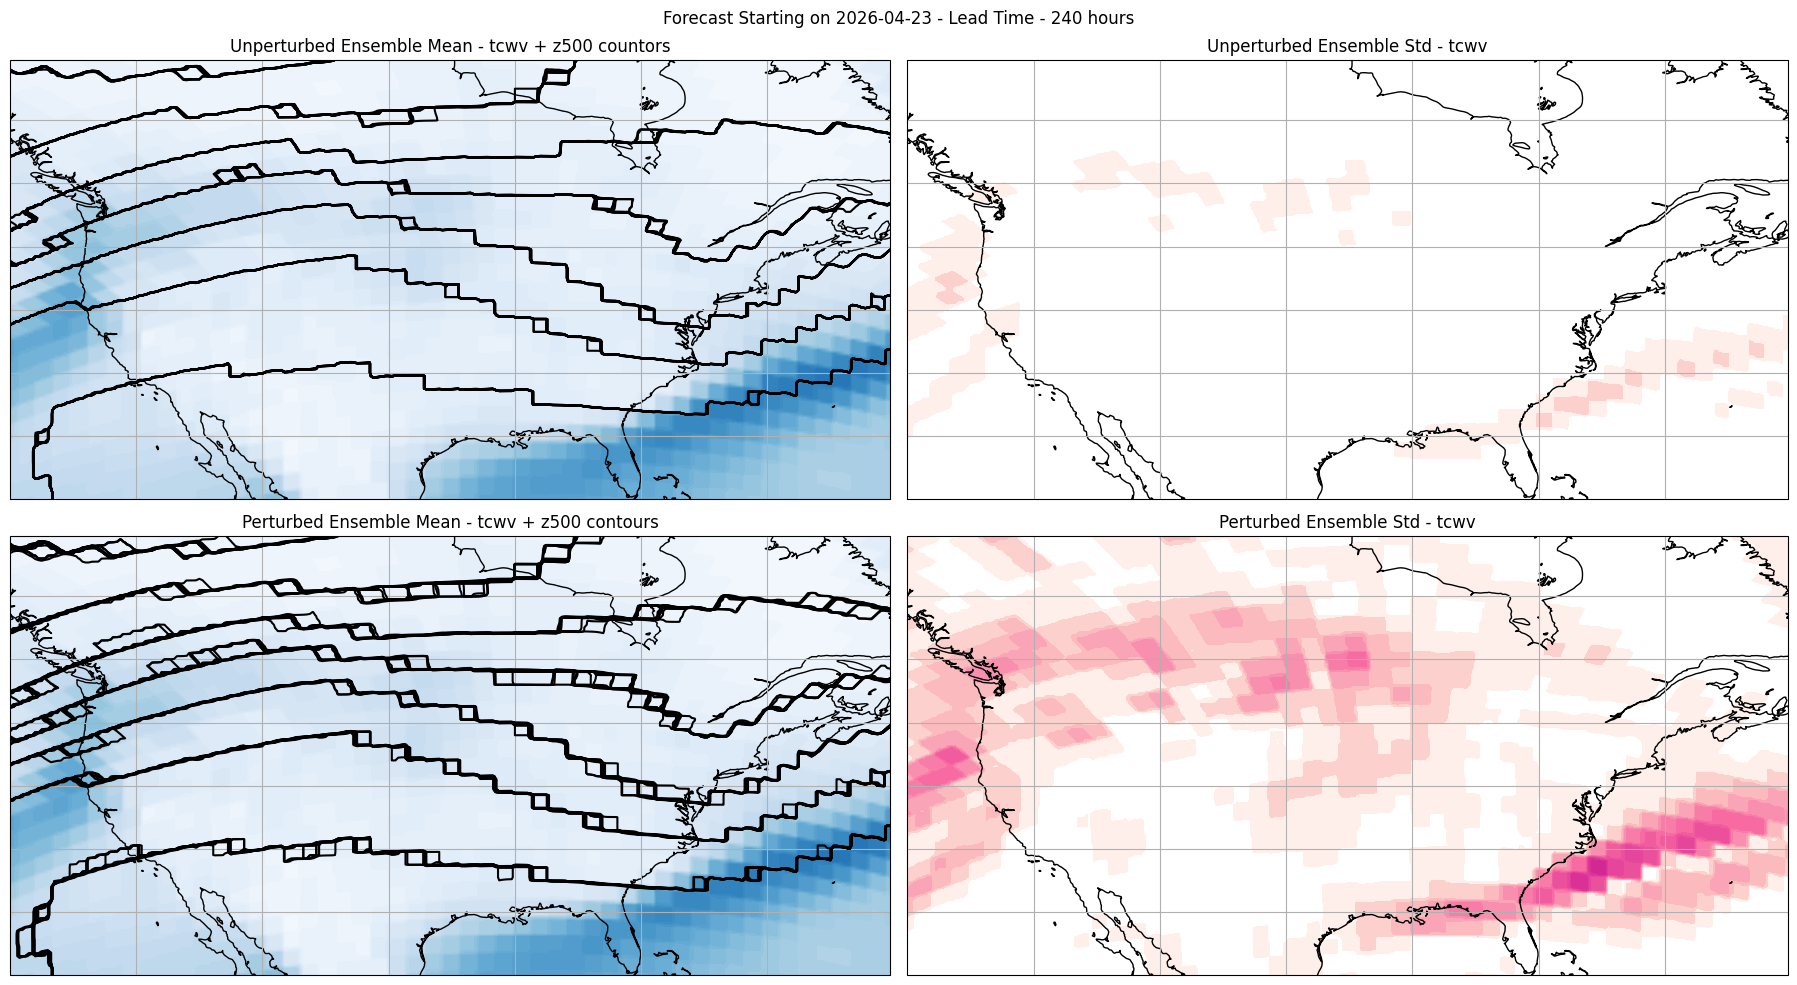

In [4]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

levels_unperturbed = np.linspace(0, io_unperturbed["tcwv"][:].max())
levels_perturbed = np.linspace(0, io_perturbed["tcwv"][:].max())


std_levels_perturbed = np.linspace(0, io_perturbed["tcwv"][:].std(axis=0).max())

plt.close("all")
fig = plt.figure(figsize=(20, 10), tight_layout=True)
ax0 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
ax1 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(2, 2, 3, projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(2, 2, 4, projection=ccrs.PlateCarree())


def update(frame):
    """This function updates the frame with a new lead time for animation."""
    import warnings

    warnings.filterwarnings("ignore")
    ax0.clear()
    ax1.clear()
    ax2.clear()
    ax3.clear()

    # #อัพเดทภาพไม่รบกวน
    im0 = ax0.contourf(
        io_unperturbed["lon"][:],
        io_unperturbed["lat"][:],
        io_unperturbed["tcwv"][:, 0, frame].mean(axis=0),
        transform=ccrs.PlateCarree(),
        cmap="Blues",
        levels=levels_unperturbed,
    )
    ax0.coastlines()
    ax0.gridlines()

    im1 = ax1.contourf(
        io_unperturbed["lon"][:],
        io_unperturbed["lat"][:],
        io_unperturbed["tcwv"][:, 0, frame].std(axis=0),
        transform=ccrs.PlateCarree(),
        cmap="RdPu",
        levels=std_levels_perturbed,
        norm=LogNorm(vmin=1e-1, vmax=std_levels_perturbed[-1]),
    )
    ax1.coastlines()
    ax1.gridlines()

    im2 = ax2.contourf(
        io_perturbed["lon"][:],
        io_perturbed["lat"][:],
        io_perturbed["tcwv"][:, 0, frame].mean(axis=0),
        transform=ccrs.PlateCarree(),
        cmap="Blues",
        levels=levels_perturbed,
    )
    ax2.coastlines()
    ax2.gridlines()

    im3 = ax3.contourf(
        io_perturbed["lon"][:],
        io_perturbed["lat"][:],
        io_perturbed["tcwv"][:, 0, frame].std(axis=0),
        transform=ccrs.PlateCarree(),
        cmap="RdPu",
        levels=std_levels_perturbed,
        norm=LogNorm(vmin=1e-1, vmax=std_levels_perturbed[-1]),
    )
    ax3.coastlines()
    ax3.gridlines()

    for i in range(16):
        ax0.contour(
            io_unperturbed["lon"][:],
            io_unperturbed["lat"][:],
            io_unperturbed["z500"][i, 0, frame] / 100.0,
            transform=ccrs.PlateCarree(),
            levels=np.arange(485, 580, 15),
            colors="black",
            linestyle="dashed",
        )

        ax2.contour(
            io_perturbed["lon"][:],
            io_perturbed["lat"][:],
            io_perturbed["z500"][i, 0, frame] / 100.0,
            transform=ccrs.PlateCarree(),
            levels=np.arange(485, 580, 15),
            colors="black",
            linestyle="dashed",
        )
    plt.suptitle(
        f'Forecast Starting on {forecast_date} - Lead Time - {io_perturbed["lead_time"][frame]}'
    )

    ax0.set_title("Unperturbed Ensemble Mean - tcwv + z500 countors")
    ax1.set_title("Unperturbed Ensemble Std - tcwv")
    ax2.set_title("Perturbed Ensemble Mean - tcwv + z500 contours")
    ax3.set_title("Perturbed Ensemble Std - tcwv")

    if frame == 0:
        plt.colorbar(
            im0, ax=ax0, shrink=0.75, pad=0.04, label="kg m^-2", format="%2.1f"
        )
        plt.colorbar(
            im1, ax=ax1, shrink=0.75, pad=0.04, label="kg m^-2", format="%1.2e"
        )
        plt.colorbar(
            im2, ax=ax2, shrink=0.75, pad=0.04, label="kg m^-2", format="%2.1f"
        )
        plt.colorbar(
            im3, ax=ax3, shrink=0.75, pad=0.04, label="kg m^-2", format="%1.2e"
        )


# ยกเลิกการแสดงความคิดเห็นสิ่งนี้สำหรับแอนิเมชั่น
# นำเข้า matplotlib.animation เป็นภาพเคลื่อนไหว
# update(0)
# ani = แอนิเมชั่น FuncAnimation(
# fig=fig, func=update, เฟรม=range(1, nsteps), cache_frame_data=เท็จ
# )
# ani.save(f"outputs/05_model_perturbation_{forecast_date}.gif", dpi=300)


for lt in [10, 20, 30, 40]:
    update(lt)
    plt.savefig(
        f"outputs/05_model_perturbation_{forecast_date}_leadtime_{lt}.png",
        dpi=300,
        bbox_inches="tight",
    )